<a href="https://colab.research.google.com/github/Rony2019-2023/secure-cxr-detection-gbm-/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from itertools import product
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

In [ ]:
# Define the directory paths for positive and negative images
covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/COVID-19'
non_covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/Normal'

In [ ]:
# Load COVID-19 images and create label array
covid_images = []
covid_labels = []
for img_name in os.listdir(covid_dir):
    img_path = os.path.join(covid_dir, img_name)
    img = keras.preprocessing.image.load_img(img_path, target_size=(256, 256))
    img_array = keras.preprocessing.image.img_to_array(img)
    covid_images.append(img_array)
    covid_labels.append(1) # Label COVID-19 images as 1

In [ ]:
# Load non-COVID-19 images and create label array
non_covid_images = []
non_covid_labels = []
for img_name in os.listdir(non_covid_dir):
    img_path = os.path.join(non_covid_dir, img_name)
    img = keras.preprocessing.image.load_img(img_path, target_size=(256, 256))
    img_array = keras.preprocessing.image.img_to_array(img)
    non_covid_images.append(img_array)
    non_covid_labels.append(0) # Label non-COVID-19 images as 0

In [ ]:
# Combine COVID-19 and non-COVID-19 images and labels into arrays
images = np.array(covid_images + non_covid_images)
labels = np.array(covid_labels + non_covid_labels)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)


In [ ]:
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# Define the model architecture
model = keras.Sequential([
    keras.layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(256, 256, 3)),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dense(units=1, activation='sigmoid')
])

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
20/20 [==============================] - 48s 2s/step - loss: 0.2734 - accuracy: 0.8990 - val_loss: 0.2720 - val_accuracy: 0.9221
Epoch 2/10
20/20 [==============================] - 46s 2s/step - loss: 0.1868 - accuracy: 0.9349 - val_loss: 0.2119 - val_accuracy: 0.9221
Epoch 3/10
20/20 [==============================] - 45s 2s/step - loss: 0.1588 - accuracy: 0.9381 - val_loss: 0.2144 - val_accuracy: 0.9221
Epoch 4/10
20/20 [==============================] - 46s 2s/step - loss: 0.1104 - accuracy: 0.9528 - val_loss: 0.2118 - val_accuracy: 0.9286
Epoch 5/10
20/20 [==============================] - 47s 2s/step - loss: 0.0737 - accuracy: 0.9723 - val_loss: 0.1841 - val_accuracy: 0.9416
Epoch 6/10
20/20 [==============================] - 50s 3s/step - loss: 0.0480 - accuracy: 0.9837 - val_loss: 0.2696 - val_accuracy: 0.9481
Epoch 7/10
20/20 [==============================] - 46s 2s/step - loss: 0.0152 - accuracy: 0.9967 - val_loss: 0.2434 - val_accuracy: 0.9286
Epoch 8/10
20/20 [==

In [ ]:
# Evaluate the model on the test set
y_pred = np.round(model.predict(X_test))
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

7/7 [==============================] - 3s 465ms/step


In [ ]:
# Print results
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('Specificity:', specificity)
print('Accuracy:', accuracy)

Precision: 1.0
Recall: 0.375
F1 Score: 0.5454545454545454
Specificity: 1.0
Accuracy: 0.9740932642487047


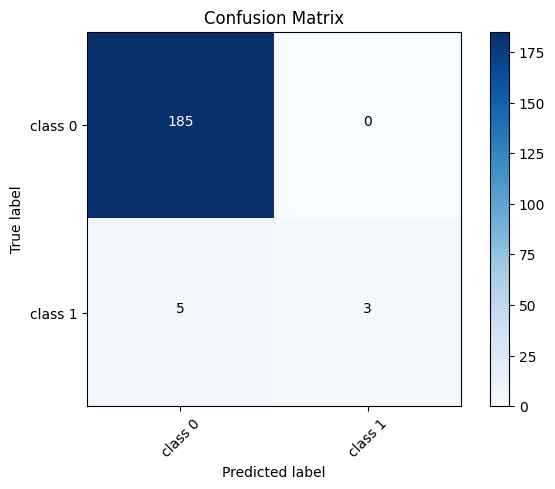

In [ ]:
# Define the classes
classes = ['class 0', 'class 1']

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
thresh = cm.max() / 2.
for i, j in product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
# Get precision and recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

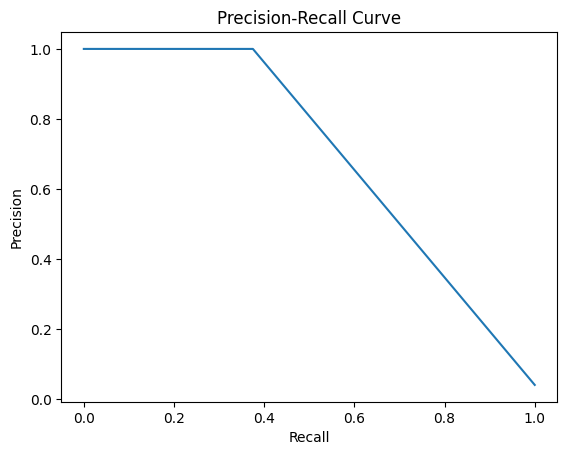

In [ ]:
# Plot the curve
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

7/7 [==============================] - 3s 452ms/step


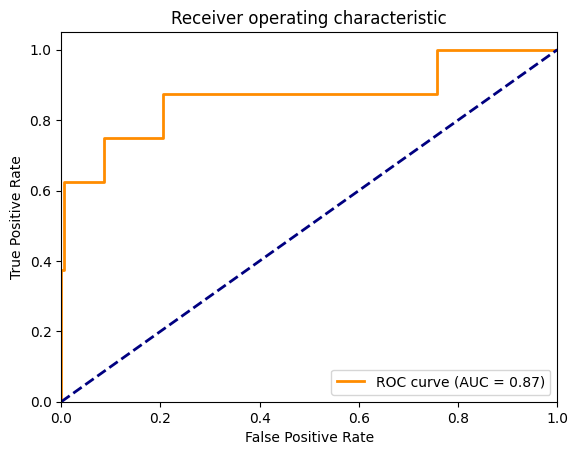

In [ ]:
# Get the predicted probabilities and true labels
y_scores = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Calculate the AUC score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

7/7 [==============================] - 8s 1s/step


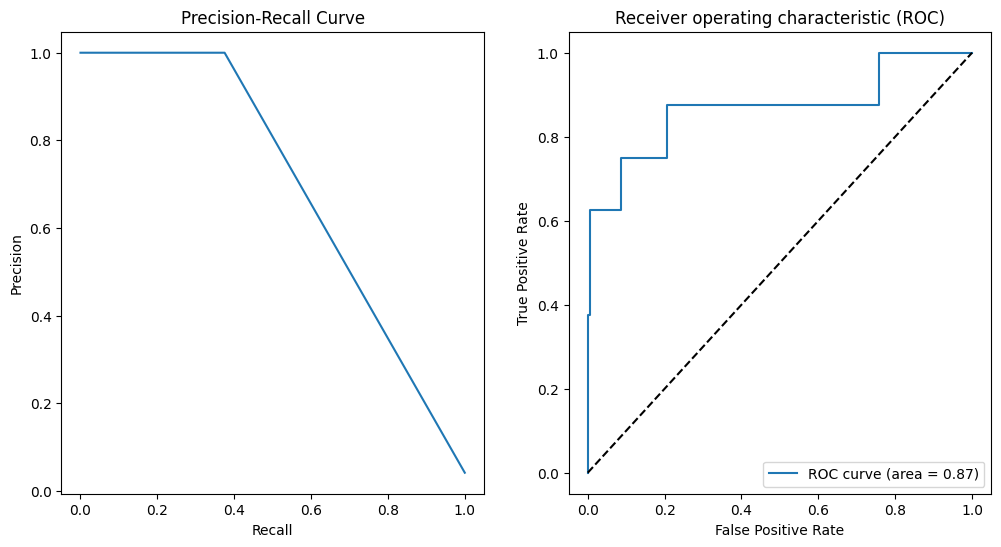

In [ ]:
# Get the predicted probabilities and true labels
y_scores = model.predict(X_test)

# Calculate the FPR and TPR at different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Get precision and recall values
precision, recall, _ = precision_recall_curve(y_test, y_pred)

# Plot the curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot the Precision-Recall curve
ax1.plot(recall, precision)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve')

# Plot the ROC curve
ax2.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
ax2.plot([0, 1], [0, 1], 'k--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Receiver operating characteristic (ROC)')

plt.legend(loc="lower right")
plt.show()